In [9]:
# Preliminary features & parameters
import src.simulations.backtest_portfolio_v2 as bp
from src import indicators

features = {
        'sma_trend_regime': {
            'func': indicators.calculate_sma_crossover,
            'params': {'fast_window': 10, 'slow_window': 30, 'binary': True},
        },
        'sma_position': {
            'func': indicators.calculate_sma_position,
            'params': {'window': 25},
        },
        'rsi': {
            'func': indicators.calculate_rsi,
            'params': {'window': 14},
        },
        'bollinger_position': {
            'func': indicators.calculate_bollinger_position,
            'params': {'window': 20, 'num_std': 2},
        },
        'price_roc': {
            'func': indicators.calculate_roc,
            'params': {'window': 5}
        }
    }

ticker_pool = [
        "NVDA", "MSFT", "AVGO", "NOW",
        "ORCL", "AAPL", "TEAM", "INTC",
        "SNOW", "WIX",  "AMD",  "CSCO",
        "SHOP", "AMZN", "CRM",
    ]
 
benchmark = "SPY"

In [10]:
# Functionize model testing & plotting
import src.stock_screener as sc
import matplotlib.pyplot as plt
import seaborn as sns

def run_with_model(input_model, features_dict):
    engine = bp.PortfolioBacktestEngine(
        model=input_model,
        feature_configs=features_dict,
        confidence_threshold=0.75,
        stop_loss=0.05,
        min_hold_days=2,
        adx_threshold=20,
        training_years=2,
        testing_years=1,
        offset_years=0
    )

    total_years = engine.training_years + engine.testing_years + engine.offset_years
    print(f"Downloading {total_years}y of data for {len(ticker_pool)} tickers + {benchmark}...")
    master_df = sc.fetch_screener_data(
        ticker_pool + [benchmark], period=f"{total_years}y", interval="1d"
    )
    print("Download Complete.")

    benchmark_prices = master_df['Close'][benchmark]
    benchmark_prices.name = benchmark

    engine.run_simulation(
        ticker_pool=ticker_pool,
        pre_downloaded_df=master_df,
        benchmark_prices=benchmark_prices,
    )

    print("\nTrade Log:")
    print(engine.last_trade_log.to_string(index=False))
    return engine, benchmark_prices

def plot_results(engine, benchmark_prices):
    sns.set_theme(style='darkgrid')
    bench = benchmark_prices.loc[engine.last_equity_curve.index]
    bench = bench / bench.iloc[0] * 10_000

    plt.figure(figsize=(12, 5))
    plt.plot(engine.last_equity_curve, label='Strategy', color='#2ecc71', linewidth=2)
    plt.plot(bench, label='Benchmark', color='#3498db', linewidth=2, linestyle='--')
    plt.title(f"Strategy {engine.last_strategy_return:+.2f}% | SPY {engine.last_benchmark_return:+.2f}% | Alpha {engine.last_alpha:+.2f}%", fontsize=13)
    plt.ylabel('Portfolio Value')
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

Fetching historical data for companies: ['NVDA', 'MSFT', 'AVGO', 'NOW', 'ORCL', 'AAPL', 'TEAM', 'INTC', 'SNOW', 'WIX', 'AMD', 'CSCO', 'SHOP', 'AMZN', 'CRM', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2023-06-23 to 2025-06-20
  Test window  : 2025-06-23 to 2026-06-22
  Strategy Return   : +2.56%
  Benchmark (SPY) : +18.16%
  Alpha             : -15.61%
  Win Rate          : 52.56%
  Total Trades      : 78

Trade Log:
     type ticker      price       date     return
      BUY    WIX 150.500000 2025-07-28        NaN
STOP_LOSS    WIX 139.369995 2025-07-30  -7.395352
      BUY    WIX 139.369995 2025-07-30        NaN
STOP_LOSS    WIX 128.970001 2025-08-01  -7.462147
      BUY   AAPL 201.580292 2025-08-01        NaN
     SELL   AAPL 202.118149 2025-08-05   0.266820
      BUY    NOW 181.024002 2025-08-05        NaN
     SELL    NOW 174.824005 2025-08-07  -3.424959
      BUY   TEAM 171.000000 2025-08-07        NaN
STOP_LOSS   TEAM 159.279999 2025-08-11  -6.853802
      BUY    NOW 171.274002 2025-08-11        NaN
     SELL    NOW 178.410004 2025-08-18   4.166424
      BUY   CSCO  65.837196 2025-08-18        NaN
     SELL   CS

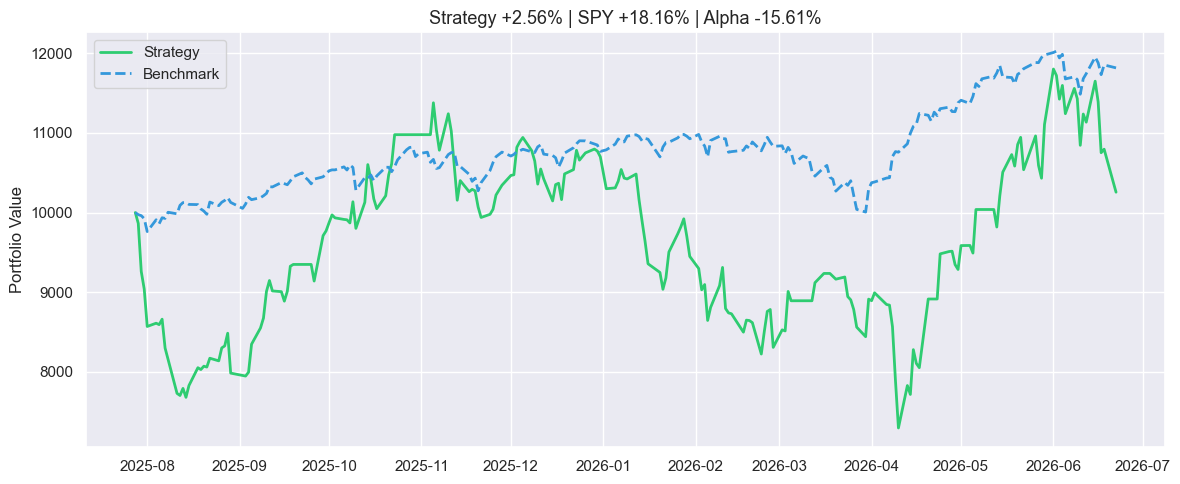

In [11]:
from sklearn import ensemble
rf_classifier = ensemble.RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        min_samples_split=10,
        max_features='sqrt',
        max_depth=10
    )
engine, benchmark_prices = run_with_model(input_model=rf_classifier, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'MSFT', 'AVGO', 'NOW', 'ORCL', 'AAPL', 'TEAM', 'INTC', 'SNOW', 'WIX', 'AMD', 'CSCO', 'SHOP', 'AMZN', 'CRM', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2023-06-23 to 2025-06-20
  Test window  : 2025-06-23 to 2026-06-22
  Strategy Return   : -16.61%
  Benchmark (SPY) : +18.16%
  Alpha             : -34.78%
  Win Rate          : 50.67%
  Total Trades      : 75

Trade Log:
     type ticker      price       date    return
      BUY   INTC  20.680000 2025-07-28       NaN
     SELL   INTC  20.340000 2025-07-30 -1.644101
      BUY    WIX 139.369995 2025-07-30       NaN
STOP_LOSS    WIX 128.970001 2025-08-01 -7.462147
      BUY    NOW 182.873993 2025-08-01       NaN
     SELL    NOW 174.501999 2025-08-08 -4.578012
      BUY   TEAM 168.059998 2025-08-08       NaN
STOP_LOSS   TEAM 159.279999 2025-08-11 -5.224324
      BUY    NOW 171.274002 2025-08-11       NaN
     SELL    NOW 170.171997 2025-08-14 -0.643416
      BUY   SNOW 194.899994 2025-08-14       NaN
     SELL   SNOW 198.240005 2025-08-18  1.713705
      BUY   CSCO  65.837204 2025-08-18       NaN
     SELL   CSCO  65.994545

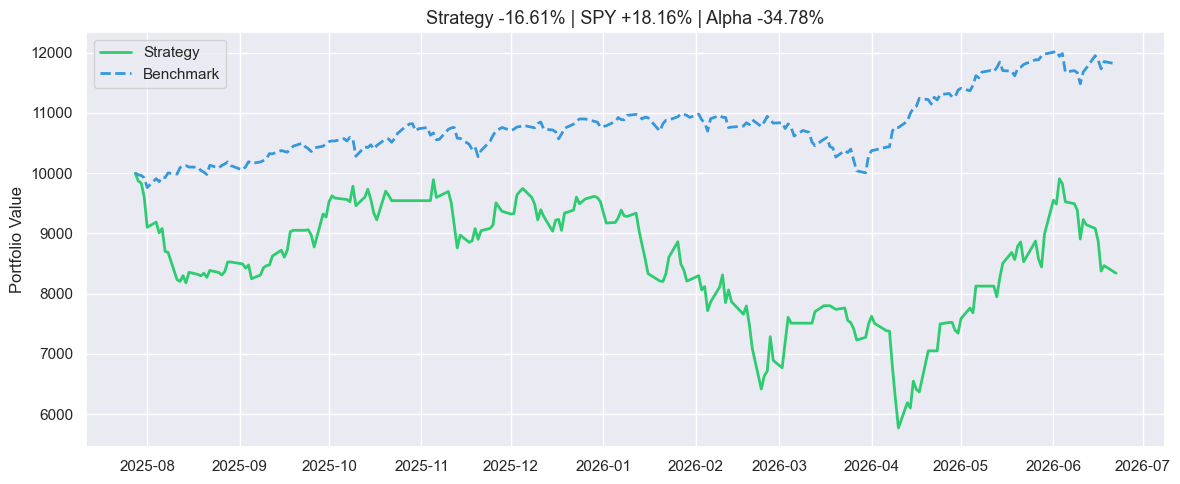

In [12]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05)

engine, benchmark_prices = run_with_model(input_model=xgb_model, features_dict=features)
plot_results(engine, benchmark_prices)

Fetching historical data for companies: ['NVDA', 'MSFT', 'AVGO', 'NOW', 'ORCL', 'AAPL', 'TEAM', 'INTC', 'SNOW', 'WIX', 'AMD', 'CSCO', 'SHOP', 'AMZN', 'CRM', 'SPY']...


[*********************100%***********************]  16 of 16 completed


Download Complete.

Portfolio Simulation Results
  Train window : 2023-06-23 to 2025-06-20
  Test window  : 2025-06-23 to 2026-06-22
  Strategy Return   : +0.28%
  Benchmark (SPY) : +18.16%
  Alpha             : -17.88%
  Win Rate          : 53.16%
  Total Trades      : 79

Trade Log:
     type ticker      price       date    return
      BUY   INTC  20.680000 2025-07-28       NaN
     SELL   INTC  20.340000 2025-07-30 -1.644101
      BUY    WIX 139.369995 2025-07-30       NaN
STOP_LOSS    WIX 128.970001 2025-08-01 -7.462147
      BUY    WIX 128.970001 2025-08-01       NaN
     SELL    WIX 133.490005 2025-08-07  3.504694
      BUY   TEAM 171.000000 2025-08-07       NaN
STOP_LOSS   TEAM 159.279999 2025-08-11 -6.853802
      BUY   TEAM 159.279999 2025-08-11       NaN
     SELL   TEAM 164.389999 2025-08-14  3.208187
      BUY    WIX 120.389999 2025-08-14       NaN
     SELL    WIX 128.770004 2025-08-18  6.960715
      BUY   CSCO  65.837204 2025-08-18       NaN
     SELL   CSCO  65.994537 

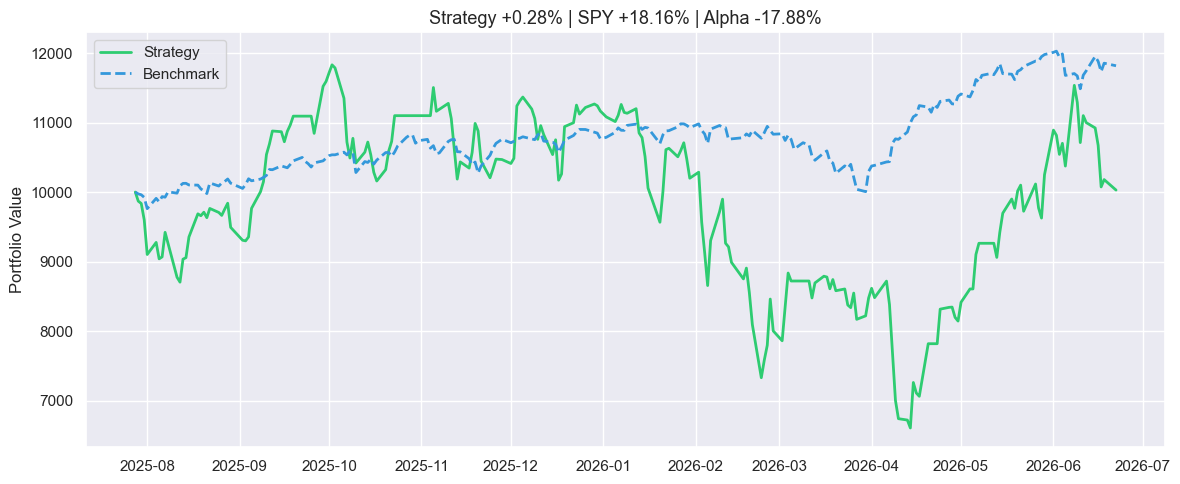

In [13]:
from sklearn.linear_model import LogisticRegression

# There was some noise based on dividing by 0, etc. that we filter out
import warnings
warnings.filterwarnings('ignore')

logreg_model = LogisticRegression(C=0.1)

engine, benchmark_prices = run_with_model(input_model=logreg_model, features_dict=features)
plot_results(engine, benchmark_prices)